In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl
from scipy.stats import kruskal, mannwhitneyu

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

# --- Load & label ---
df_gh = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/interaction_type_bout.csv')
df_gh['condition'] = 'group-housed'

df_gs = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/grouped+isolated/interaction_type_bout.csv')
df_gs['condition'] = 'mixed'

df_si = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/socially-isolated/interaction_type_bout.csv')
df_si['condition'] = 'socially-isolated'

df = pd.concat([df_gh, df_gs, df_si], ignore_index=True)

# --- Helper: merge overlapping intervals, return total covered frames ---
def covered_frames(intervals):
    merged = []
    for start, end in sorted(intervals):
        if merged and start <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], end))
        else:
            merged.append([start, end])
    return sum(e - s + 1 for s, e in merged)

# fps = 1, recording = 3600 s
TOTAL_SECONDS = 3600

df_melted = pd.melt(
    df,
    id_vars=['file', 'condition', 'start_frame', 'end_frame'],
    value_vars=['track_1', 'track_2'],
    value_name='larva'
).drop(columns='variable')

proportion_overall = (
    df_melted
    .groupby(['condition', 'file', 'larva'])
    .apply(lambda g: covered_frames(zip(g['start_frame'], g['end_frame'])))
    .reset_index(name='contact_seconds')
)
proportion_overall['proportion'] = proportion_overall['contact_seconds'] / TOTAL_SECONDS

proportion_overall.head()


,condition,file,larva,contact_seconds,proportion
0,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0,346,0.096111
1,group-housed,2025-02-24_11-59-11_td14.tracks.feather,1,201,0.055833
2,group-housed,2025-02-24_11-59-11_td14.tracks.feather,2,223,0.061944
3,group-housed,2025-02-24_11-59-11_td14.tracks.feather,3,188,0.052222
4,group-housed,2025-02-24_11-59-11_td14.tracks.feather,4,138,0.038333


In [7]:
# --- Proportion binned into 600-second intervals ---
BIN_SIZE = 600

df['time_bin'] = (df['start_frame'] // BIN_SIZE) * BIN_SIZE

df_melted_bins = pd.melt(
    df,
    id_vars=['file', 'condition', 'start_frame', 'end_frame', 'time_bin'],
    value_vars=['track_1', 'track_2'],
    value_name='larva'
).drop(columns='variable')

proportion_binned = (
    df_melted_bins
    .groupby(['condition', 'file', 'larva', 'time_bin'])
    .apply(lambda g: covered_frames(zip(g['start_frame'], g['end_frame'])))
    .reset_index(name='contact_seconds')
)
proportion_binned['proportion'] = proportion_binned['contact_seconds'] / BIN_SIZE

proportion_binned.head()


,condition,file,larva,time_bin,contact_seconds,proportion
0,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0,0,63,0.105
1,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0,600,135,0.225
2,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0,1200,60,0.100
3,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0,1800,9,0.015
4,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0,2400,45,0.075


Kruskal-Wallis H = 13.85, p = 0.0010
GH vs GS: U=98.0, p_bonf=0.0402
GH vs SI: U=92.0, p_bonf=0.0051
GS vs SI: U=94.0, p_bonf=0.0815


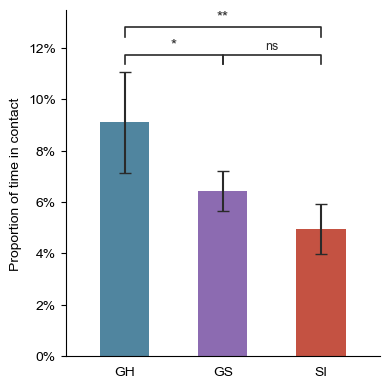

In [8]:
# --- Barplot: overall proportion per condition ---
COLORS = {'group-housed': '#50859f', 'mixed': '#8c6bb1', 'socially-isolated': '#c45242'}
LABELS = {'group-housed': 'GH', 'mixed': 'GS', 'socially-isolated': 'SI'}
CONDITIONS = ['group-housed', 'mixed', 'socially-isolated']

per_video_overall = (
    proportion_overall
    .groupby(['condition', 'file'])['proportion']
    .mean()
    .reset_index()
)

# Kruskal-Wallis across all three conditions
groups = [per_video_overall[per_video_overall['condition'] == c]['proportion'].values for c in CONDITIONS]
h_stat, p_kw = kruskal(*groups)
print(f'Kruskal-Wallis H = {h_stat:.2f}, p = {p_kw:.4f}')

# Pairwise Mann-Whitney with Bonferroni correction (3 comparisons)
pairs = [('group-housed', 'mixed'), ('group-housed', 'socially-isolated'), ('mixed', 'socially-isolated')]
pw_results = {}
for a, b in pairs:
    u, p = mannwhitneyu(
        per_video_overall[per_video_overall['condition'] == a]['proportion'].values,
        per_video_overall[per_video_overall['condition'] == b]['proportion'].values,
        alternative='two-sided'
    )
    p_corr = min(p * 3, 1.0)  # Bonferroni
    pw_results[(a, b)] = p_corr
    print(f'{LABELS[a]} vs {LABELS[b]}: U={u:.1f}, p_bonf={p_corr:.4f}')

def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

fig, ax = plt.subplots(figsize=(4, 4))

for i, cond in enumerate(CONDITIONS):
    vals = per_video_overall[per_video_overall['condition'] == cond]['proportion'].values
    mean = vals.mean()
    ci   = 1.96 * vals.std(ddof=1) / np.sqrt(len(vals))
    ax.bar(i, mean, width=0.5, color=COLORS[cond], zorder=2, clip_on=False)
    ax.errorbar(i, mean, yerr=ci, color='#2a2a2a', capsize=4,
                linewidth=1.5, zorder=3, linestyle='none')

# Significance brackets
def draw_bracket(ax, x1, x2, y_bracket, y_tip, label):
    ax.plot([x1, x1, x2, x2], [y_tip, y_bracket, y_bracket, y_tip],
            color='#2a2a2a', linewidth=1.2)
    ax.text((x1 + x2) / 2, y_bracket * 1.01, label,
            ha='center', va='bottom', fontsize=11 if label != 'ns' else 9, color='#2a2a2a')

ci_tops = []
for cond in CONDITIONS:
    vals = per_video_overall[per_video_overall['condition'] == cond]['proportion'].values
    ci_tops.append(vals.mean() + 1.96 * vals.std(ddof=1) / np.sqrt(len(vals)))

y0   = max(ci_tops) * 1.06
step = max(ci_tops) * 0.10

bracket_pairs = [
    (0, 1, ('group-housed', 'mixed'),            y0),
    (1, 2, ('mixed', 'socially-isolated'),        y0),
    (0, 2, ('group-housed', 'socially-isolated'), y0 + step),
]
for x1, x2, pair, y_b in bracket_pairs:
    draw_bracket(ax, x1, x2, y_b, y_b * 0.97, p_to_stars(pw_results[pair]))

ax.set_xticks([0, 1, 2])
ax.set_xticklabels([LABELS[c] for c in CONDITIONS])
ax.set_ylabel('Proportion of time in contact')
ax.set_xlim(-0.6, 2.6)
ax.set_ylim(0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(bottom=False)
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-2/group+iso(mixed)/proportion_overall_3cond.pdf', bbox_inches='tight')
plt.show()


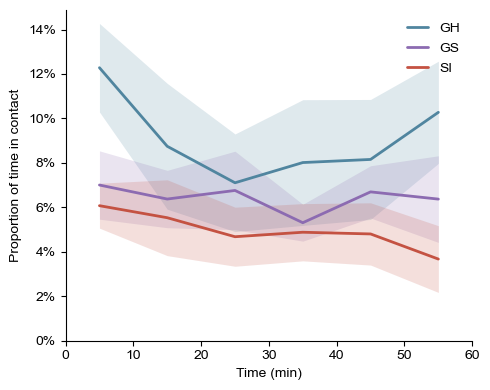

In [9]:
# --- Lineplot: proportion over time with 95% CI ---
COLORS = {'group-housed': '#50859f', 'mixed': '#8c6bb1', 'socially-isolated': '#c45242'}
LABELS = {'group-housed': 'GH', 'mixed': 'GS', 'socially-isolated': 'SI'}
CONDITIONS = ['group-housed', 'mixed', 'socially-isolated']
BIN_SIZE = 600

# Fill zeros for larvae with no contact in a bin
all_larvae = proportion_binned[['condition', 'file', 'larva']].drop_duplicates()
all_bins   = pd.DataFrame({'time_bin': sorted(proportion_binned['time_bin'].unique())})
full_index = all_larvae.merge(all_bins, how='cross')

proportion_binned_full = (
    full_index
    .merge(proportion_binned, on=['condition', 'file', 'larva', 'time_bin'], how='left')
    .fillna({'contact_seconds': 0, 'proportion': 0})
)

per_video_binned = (
    proportion_binned_full
    .groupby(['condition', 'file', 'time_bin'])['proportion']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 4))

for cond in CONDITIONS:
    data  = per_video_binned[per_video_binned['condition'] == cond]
    stats = (
        data.groupby('time_bin')['proportion']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    stats['ci'] = 1.96 * stats['std'] / np.sqrt(stats['count'])
    x = (stats['time_bin'] + BIN_SIZE / 2) / 60

    ax.plot(x, stats['mean'], color=COLORS[cond], linewidth=2,
            label=LABELS[cond], solid_capstyle='round')
    ax.fill_between(x,
                    stats['mean'] - stats['ci'],
                    stats['mean'] + stats['ci'],
                    color=COLORS[cond], alpha=0.18, linewidth=0)

ax.set_xlabel('Time (min)')
ax.set_ylabel('Proportion of time in contact')
ax.set_xlim(0, 60)
ax.set_ylim(0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, handlelength=1.5)
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-2/group+iso(mixed)/proportion_over_time_3cond.pdf', bbox_inches='tight')
plt.show()
